**LAB EXPERIMENT - 4**\
**Probabilistic Classification using Naïve Bayes (Gaussian & Multinomial Naïve Bayes)**

Name : Poovika M\
Roll No : 24BAD087

**SCENARIO 1**

**CODE INTERPRETATION**
 1. Import Libraries

    Required libraries for data handling, text processing, visualization, and machine learning are imported.

 2. Load Dataset

    The SMS spam dataset is loaded using pandas.
    Only the label (ham/spam) and message columns are selected and renamed.

 3. Text Preprocessing

    A cleaning function is applied to:
        

       *   Convert text to lowercase
       *   Remove punctuation
       *   Remove numbers

    This prepares the text for model training.

 4. Feature Extraction

    CountVectorizer converts text messages into numerical form using the Bag-of-Words method.
    Stop words are removed to reduce unnecessary features.

 5. Encode Target Labels

    The labels are converted into numeric form:

    Ham → 0

    Spam → 1

 6. Train-Test Split

    The dataset is split into:


      *   80% training data
      *   20% testing data



 7. Model Training

    A Multinomial Naïve Bayes classifier is trained using Laplace smoothing (alpha = 1.0).

 8. Prediction

    The trained model predicts whether test messages are spam or ham.

 9. Model Evaluation

    Performance is measured using:


      *   Accuracy
      *   Precision

      *   Recall

      *   F1-score
      *   Confusion Matrix




 10. Additional Analysis


*   Misclassified messages are displayed.
*   Model performance is compared without Laplace smoothing.

*   Graphs are plotted for confusion matrix and top spam/ham words.




POOVIKA M - 24BAD087
Dataset Shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Feature Matrix Shape: (5572, 8293)
Training Size: (4457, 8293)
Testing Size: (1115, 8293)

========== MODEL PERFORMANCE ==========
Accuracy  : 0.9704035874439462
Precision : 0.8726114649681529
Recall    : 0.9133333333333333
F1 Score  : 0.8925081433224755

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       965
           1       0.87      0.91      0.89       150

    accuracy                           0.97      1115
   macro avg       0.93      0.95      0.94      1115
weighted avg       0.97      0.97      0.97     

/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:898: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(


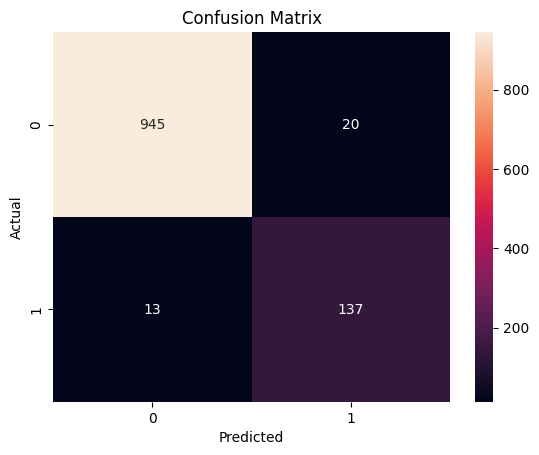

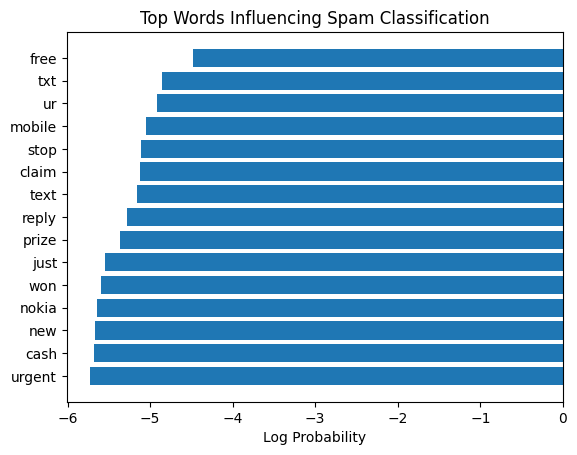

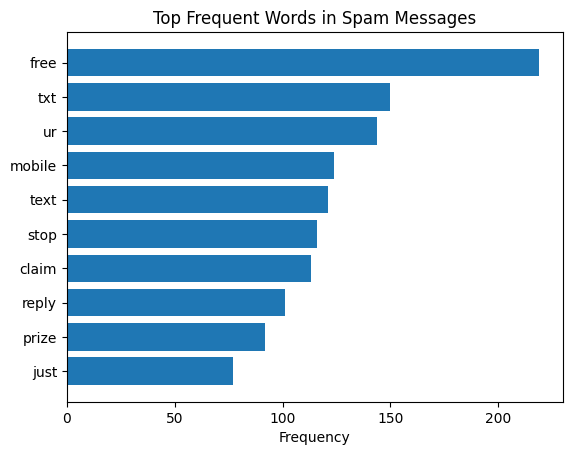

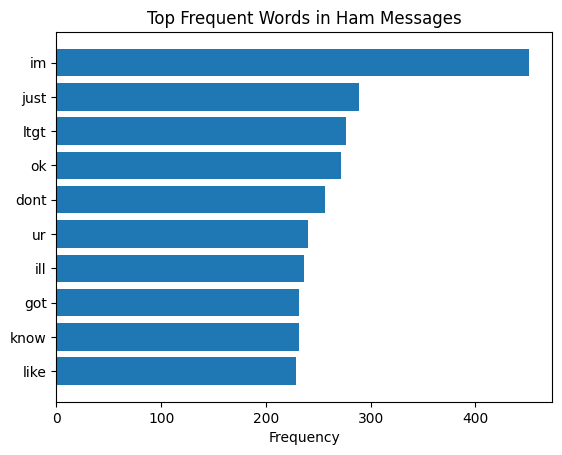

In [ ]:
#POOVIKA M - 24BAD087
#EXP_4 : SCENARIO 1

print("POOVIKA M - 24BAD087")
#IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#LOAD DATASET
df = pd.read_csv(r"/content/sample_data/spam.csv", encoding="latin-1")

#Keep only necessary columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Dataset Shape:", df.shape)
print(df.head())

#DATA PREPROCESSING
# Text Cleaning Function
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    return text

df['message'] = df['message'].apply(clean_text)

#CONVERT TEXT INTO NUMERICAL FEATURES (COUNT VECTORIZATION)
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])

print("Feature Matrix Shape:", X.shape)

#ENCODE TARGET LABELS
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])   # Ham = 0, Spam = 1

#SPLIT DATASET INTO TRAIN & TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

#TRAIN MULTINOMIAL NAÏVE BAYES CLASSIFIER
model = MultinomialNB(alpha=1.0)   # Laplace smoothing
model.fit(X_train, y_train)

#PREDICT MESSAGE CLASSES
y_pred = model.predict(X_test)

#EVALUATE PERFORMANCE
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

#MISCLASSIFIED EXAMPLES
misclassified_indices = np.where(y_test != y_pred)[0]
print("\nNumber of Misclassified Messages:", len(misclassified_indices))

#Display few misclassified examples
for i in misclassified_indices[:5]:
    print("\nActual:", encoder.inverse_transform([y_test[i]])[0])
    print("Predicted:", encoder.inverse_transform([y_pred[i]])[0])

#LAPLACE SMOOTHING IMPACT
model_no_smoothing = MultinomialNB(alpha=0.0)
model_no_smoothing.fit(X_train, y_train)
y_pred_no = model_no_smoothing.predict(X_test)

print("\nAccuracy without Laplace Smoothing:",
      accuracy_score(y_test, y_pred_no))

#VISUALIZATIONS
#CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#TOP WORDS INFLUENCING SPAM CLASSIFICATION
feature_names = vectorizer.get_feature_names_out()
spam_prob = model.feature_log_prob_[1]

top_spam_indices = np.argsort(spam_prob)[-15:]
top_spam_words = [feature_names[i] for i in top_spam_indices]

plt.figure()
plt.barh(top_spam_words, spam_prob[top_spam_indices])
plt.title("Top Words Influencing Spam Classification")
plt.xlabel("Log Probability")
plt.show()

#WORD FREQUENCY COMPARISON (SPAM vs HAM)
spam_messages = df[df['label'] == 'spam']['message']
ham_messages = df[df['label'] == 'ham']['message']

spam_vector = CountVectorizer(stop_words='english')
ham_vector = CountVectorizer(stop_words='english')

spam_counts = spam_vector.fit_transform(spam_messages)
ham_counts = ham_vector.fit_transform(ham_messages)

spam_sum = np.array(spam_counts.sum(axis=0)).flatten()
ham_sum = np.array(ham_counts.sum(axis=0)).flatten()

spam_words = spam_vector.get_feature_names_out()
ham_words = ham_vector.get_feature_names_out()

top_spam = spam_words[np.argsort(spam_sum)[-10:]]
top_ham = ham_words[np.argsort(ham_sum)[-10:]]

plt.figure()
plt.barh(top_spam, sorted(spam_sum)[-10:])
plt.title("Top Frequent Words in Spam Messages")
plt.xlabel("Frequency")
plt.show()

plt.figure()
plt.barh(top_ham, sorted(ham_sum)[-10:])
plt.title("Top Frequent Words in Ham Messages")
plt.xlabel("Frequency")
plt.show()





**SCENARIO 2**

**CODE INTERPRETATION**
 1. Import Libraries

    Necessary libraries are imported for data handling, visualization, preprocessing, model building, and evaluation.

 2. Load Dataset

    The Iris dataset is loaded using load_iris() from sklearn.

    Input Features: Sepal length, Sepal width, Petal length, Petal width

    Target: Flower species (3 classes)

    The dataset is converted into a DataFrame for inspection.

 3. Data Inspection

    Dataset shape and first few rows are displayed.

    Class distribution is checked.

    Statistical summary and missing values are verified.

 4. Feature Scaling

    StandardScaler is applied to standardize the feature values.
    This ensures all features are on the same scale.

 5. Train-Test Split

    The dataset is divided into:


       *   80% training data
       *   20% testing data


 6. Train Gaussian Naïve Bayes

    A Gaussian Naïve Bayes classifier is trained.
    It is suitable for continuous numerical data and assumes normal distribution.

 7. Prediction

    The trained model predicts the species of test samples.

 8. Model Evaluation

    Performance is evaluated using:


    *   Accuracy
    *   Precision

    *   Recall

    *   F1-score
    *   Classification Report


    A comparison of actual vs predicted labels is displayed.

 9. Class Probabilities

    The model calculates predicted probabilities for each class using predict_proba().

 10. Comparison with Logistic Regression

     Logistic Regression model is trained and its accuracy is compared with Gaussian Naïve Bayes.

 11. Visualizations

     Confusion Matrix → Shows correct and incorrect classifications.

     Decision Boundary (2D) → Visualizes classification regions using first two features.

     Probability Distribution Plot → Shows distribution of predicted probabilities for each class.

POOVIKA M - 24BAD087
Dataset Shape: (150, 5)

First 5 Rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Class Distribution:
 species
0    50
1    50
2    50
Name: count, dtype: int64

Statistical Summary:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.30000

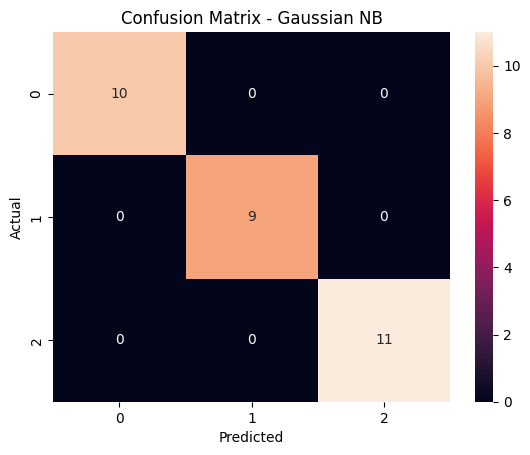

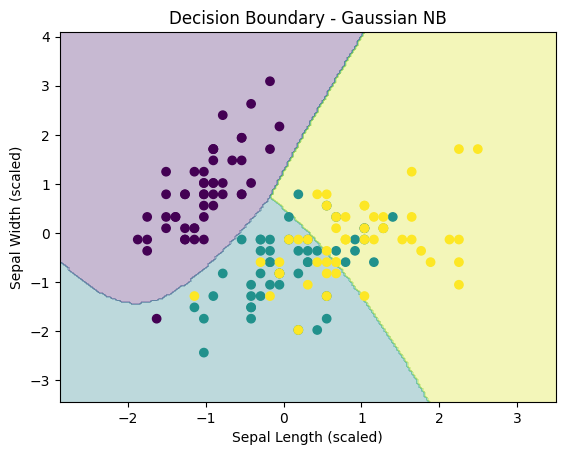

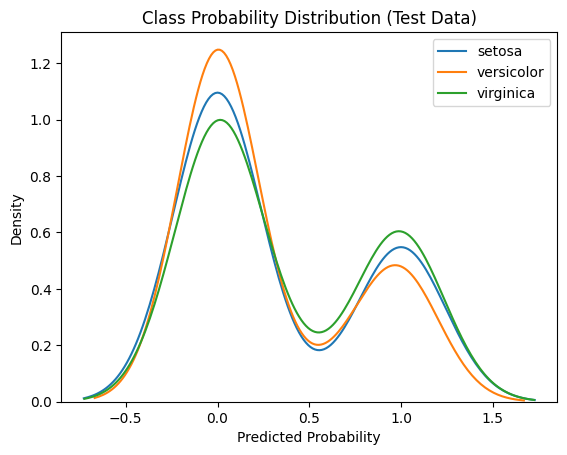

In [ ]:
#POOVIKA M - 24BAD087
#EXP_4 : SCENARIO 2

print("POOVIKA M - 24BAD087")
#IMPORT REQUIRED LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#LOAD THE IRIS DATASET
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = y

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())
print("\nClass Distribution:\n", df['species'].value_counts())

#DATA INSPECTION & PREPROCESSING
print("\nStatistical Summary:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())

#FEATURE SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#SPLIT DATASET
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

#TRAIN GAUSSIAN NAÏVE BAYES
gnb = GaussianNB()
gnb.fit(X_train, y_train)

#PREDICT SPECIES LABELS
y_pred = gnb.predict(X_test)

#EVALUATE PERFORMANCE
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n========== GAUSSIAN NB PERFORMANCE ==========")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

#COMPARE PREDICTIONS WITH ACTUAL LABELS
comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nComparison of Actual vs Predicted (First 10):")
print(comparison_df.head(10))

#ANALYZE CLASS PROBABILITIES
probabilities = gnb.predict_proba(X_test)

print("\nClass Probabilities for First 5 Test Samples:\n")
print(probabilities[:5])

#COMPARE WITH LOGISTIC REGRESSION (OPTIONAL)
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\n========== LOGISTIC REGRESSION PERFORMANCE ==========")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

#VISUALIZATIONS
#CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gaussian NB")
plt.show()

#DECISION BOUNDARY (Using First Two Features)
# Use only first two features for 2D plotting
X_two = X_scaled[:, :2]
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_two, y, test_size=0.2, random_state=42
)

model_2D = GaussianNB()
model_2D.fit(X_train_2, y_train_2)

# Create mesh grid
x_min, x_max = X_two[:, 0].min() - 1, X_two[:, 0].max() + 1
y_min, y_max = X_two[:, 1].min() - 1, X_two[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_two[:, 0], X_two[:, 1], c=y)
plt.xlabel("Sepal Length (scaled)")
plt.ylabel("Sepal Width (scaled)")
plt.title("Decision Boundary - Gaussian NB")
plt.show()

#PROBABILITY DISTRIBUTION PLOTS
plt.figure()
for i in range(3):
    sns.kdeplot(probabilities[:, i], label=target_names[i])

plt.title("Class Probability Distribution (Test Data)")
plt.xlabel("Predicted Probability")
plt.legend()
plt.show()



